<a href="https://colab.research.google.com/github/hvsya/AI-Project_PlantVillage/blob/main/DataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization — Plant Disease Classification
**Role:** Data Analyst  

Visualises the performance of all three CNN models trained in `DataModeling.ipynb`:  
ResNet50 · DenseNet121 · MobileNetV3Small

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_FOLDER = '/content/drive/MyDrive/AI_Project'
os.chdir(PROJECT_FOLDER)
print('Working directory:', os.getcwd())
print('Files found:')
for f in sorted(os.listdir('.')):
    print(' ', f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/AI_Project
Files found:
  DataModeling.ipynb
  DataPreparation.ipynb
  DataVisualization.ipynb
  best_densenet121.keras
  best_mobilenetv3.keras
  best_resnet50.keras
  final_plantvillage_dataset
  model_results.json


In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Small
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_pre
from tensorflow.keras.applications.densenet     import preprocess_input as densenet_pre
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_pre
from sklearn.metrics import (
    confusion_matrix, classification_report, average_precision_score
)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})
COLORS = {
    'ResNet50':          '#E63946',
    'DenseNet121':       '#457B9D',
    'MobileNetV3Small':  '#2A9D8F'
}
print('Libraries loaded. TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

Libraries loaded. TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load model_results.json (history + metrics)

In [8]:
with open('model_results.json') as f:
    data = json.load(f)

CLASS_NAMES = data['class_names']
results     = data['results']
NUM_CLASSES = len(CLASS_NAMES)

print('model_results.json loaded.')
print('Models :', list(results.keys()))
print('Classes:', CLASS_NAMES)

model_results.json loaded.
Models : ['ResNet50', 'DenseNet121', 'MobileNetV3Small']
Classes: ['Apple_Black_rot', 'Apple_Cedar_apple_rust', 'Apple_healthy', 'Apple_scab', 'Blueberry_healthy', 'Corn_Common_rust', 'Grape_Black_rot', 'Peach_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_healthy']


---
# Rebuild Model Architectures & Load Saved Weights
> Rebuild the same architecture as DataModeling, then call `load_weights()`  
> which only reads the weight values

In [9]:
OUTPUT_DIR  = 'final_plantvillage_dataset'
TARGET_SIZE = (224, 224)
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE

# ── Rebuild the same architecture used in DataModeling ────────────────────
def build_model(backbone_cls, preprocess_fn, name):
    """Exact same architecture as DataModeling.ipynb."""
    inputs = keras.Input(shape=(224, 224, 3), name='input_image')
    x      = layers.Lambda(preprocess_fn, name='preprocess')(inputs)
    base   = backbone_cls(include_top=False, weights=None, input_tensor=x)
    x      = layers.GlobalAveragePooling2D()(base.output)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dense(256, activation='relu')(x)
    x      = layers.Dropout(0.4)(x)
    out    = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model  = Model(inputs, out, name=name)
    return model


# ── Load weights only (bypasses the serialization error) ──────────────────
model_configs = [
    ('ResNet50',         ResNet50,        resnet_pre,    'best_resnet50.keras'),
    ('DenseNet121',      DenseNet121,     densenet_pre,  'best_densenet121.keras'),
    ('MobileNetV3Small', MobileNetV3Small, mobilenet_pre, 'best_mobilenetv3.keras'),
]

loaded_models = {}
for model_name, backbone_cls, preprocess_fn, weight_file in model_configs:
    print(f'\nRebuilding {model_name}...')
    model = build_model(backbone_cls, preprocess_fn, model_name)

    if os.path.exists(weight_file):
        # load_weights() reads ONLY the weight values — no Lambda deserialization
        model.load_weights(weight_file)
        print(f'Weights loaded from {weight_file}')
    else:
        print(f'{weight_file} not found — predictions will be random for this model')

    loaded_models[model_name] = model

print('\nAll models ready.')


Rebuilding ResNet50...
Weights loaded from best_resnet50.keras

Rebuilding DenseNet121...
Weights loaded from best_densenet121.keras

Rebuilding MobileNetV3Small...
Weights loaded from best_mobilenetv3.keras

All models ready.


---
# Run Predictions on Test Set

In [10]:
# Load raw test images
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUTPUT_DIR, 'test'),
    image_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=False
)

def cast(x, y):
    return tf.cast(x, tf.float32), y

test_ds_prep = test_ds_raw.map(cast, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# True labels
y_true_onehot = np.concatenate([y.numpy() for _, y in test_ds_prep], axis=0)
y_true        = np.argmax(y_true_onehot, axis=1)

# Predict with each model
y_probs, y_preds = {}, {}
pred_aps = {}

for name, model in loaded_models.items():
    print(f'Predicting with {name}...')
    probs = model.predict(test_ds_prep, verbose=0)
    y_probs[name] = probs
    y_preds[name] = np.argmax(probs, axis=1)

    # Recompute per-class AP from live predictions (more accurate than JSON)
    aps = [average_precision_score(y_true_onehot[:, i], probs[:, i])
           for i in range(NUM_CLASSES)]
    pred_aps[name]              = aps
    results[name]['per_class_AP'] = aps
    results[name]['mAP']          = float(np.mean(aps))

print('\nPredictions complete.')
print(f'   Test samples: {len(y_true)}')

Found 900 files belonging to 10 classes.
Predicting with ResNet50...
Predicting with DenseNet121...
Predicting with MobileNetV3Small...

Predictions complete.
   Test samples: 900


---
# 1. Dataset Distribution

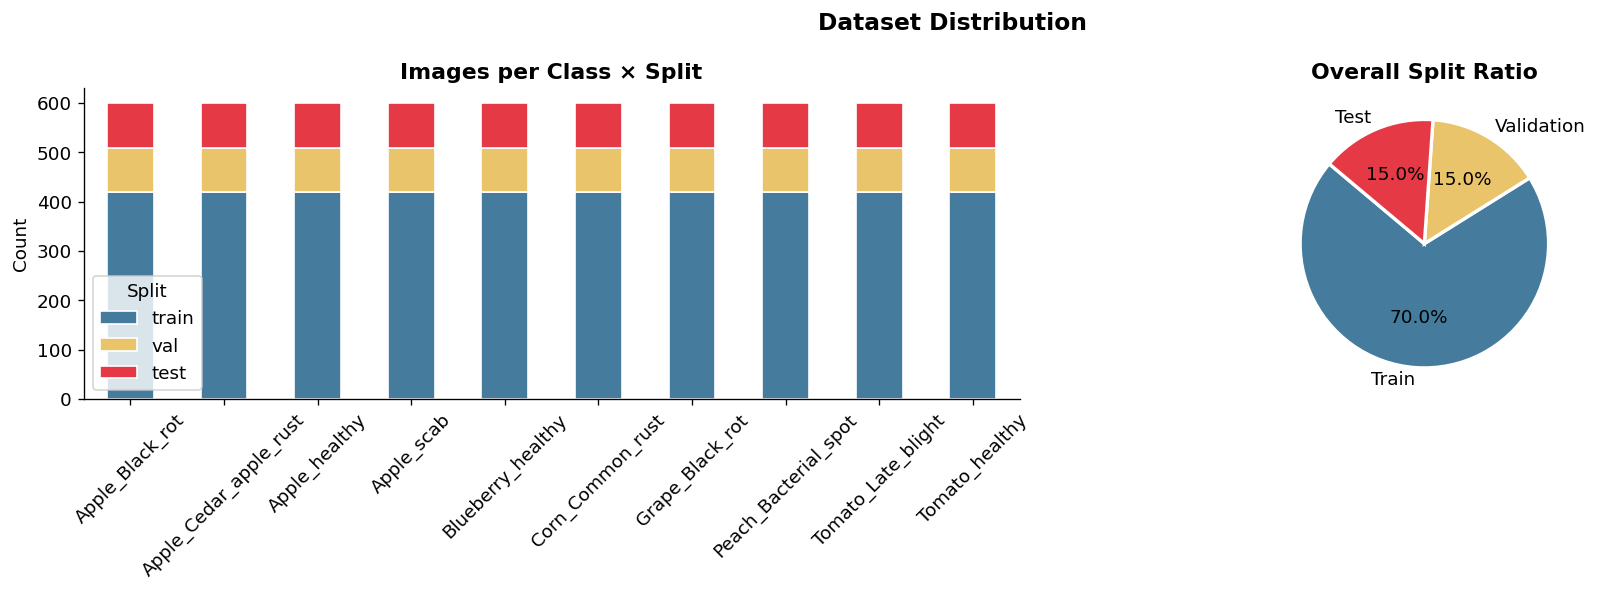

Saved viz_01_dataset_distribution.png


In [11]:
split_counts = {}
for split in ['train', 'val', 'test']:
    split_counts[split] = {}
    for cls in CLASS_NAMES:
        p = os.path.join(OUTPUT_DIR, split, cls)
        split_counts[split][cls] = len(os.listdir(p)) if os.path.isdir(p) else 0

df_c = pd.DataFrame(split_counts).fillna(0).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_c[['train','val','test']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#457B9D','#E9C46A','#E63946'], edgecolor='white')
axes[0].set_title('Images per Class × Split', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Split')

totals = [df_c[s].sum() for s in ['train','val','test']]
axes[1].pie(totals, labels=['Train','Validation','Test'],
            autopct='%1.1f%%',
            colors=['#457B9D','#E9C46A','#E63946'],
            startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Overall Split Ratio', fontweight='bold')

plt.suptitle('Dataset Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_01_dataset_distribution.png', bbox_inches='tight')
plt.show()
print('Saved viz_01_dataset_distribution.png')

---
# 2. Training Curves (from model_results.json)

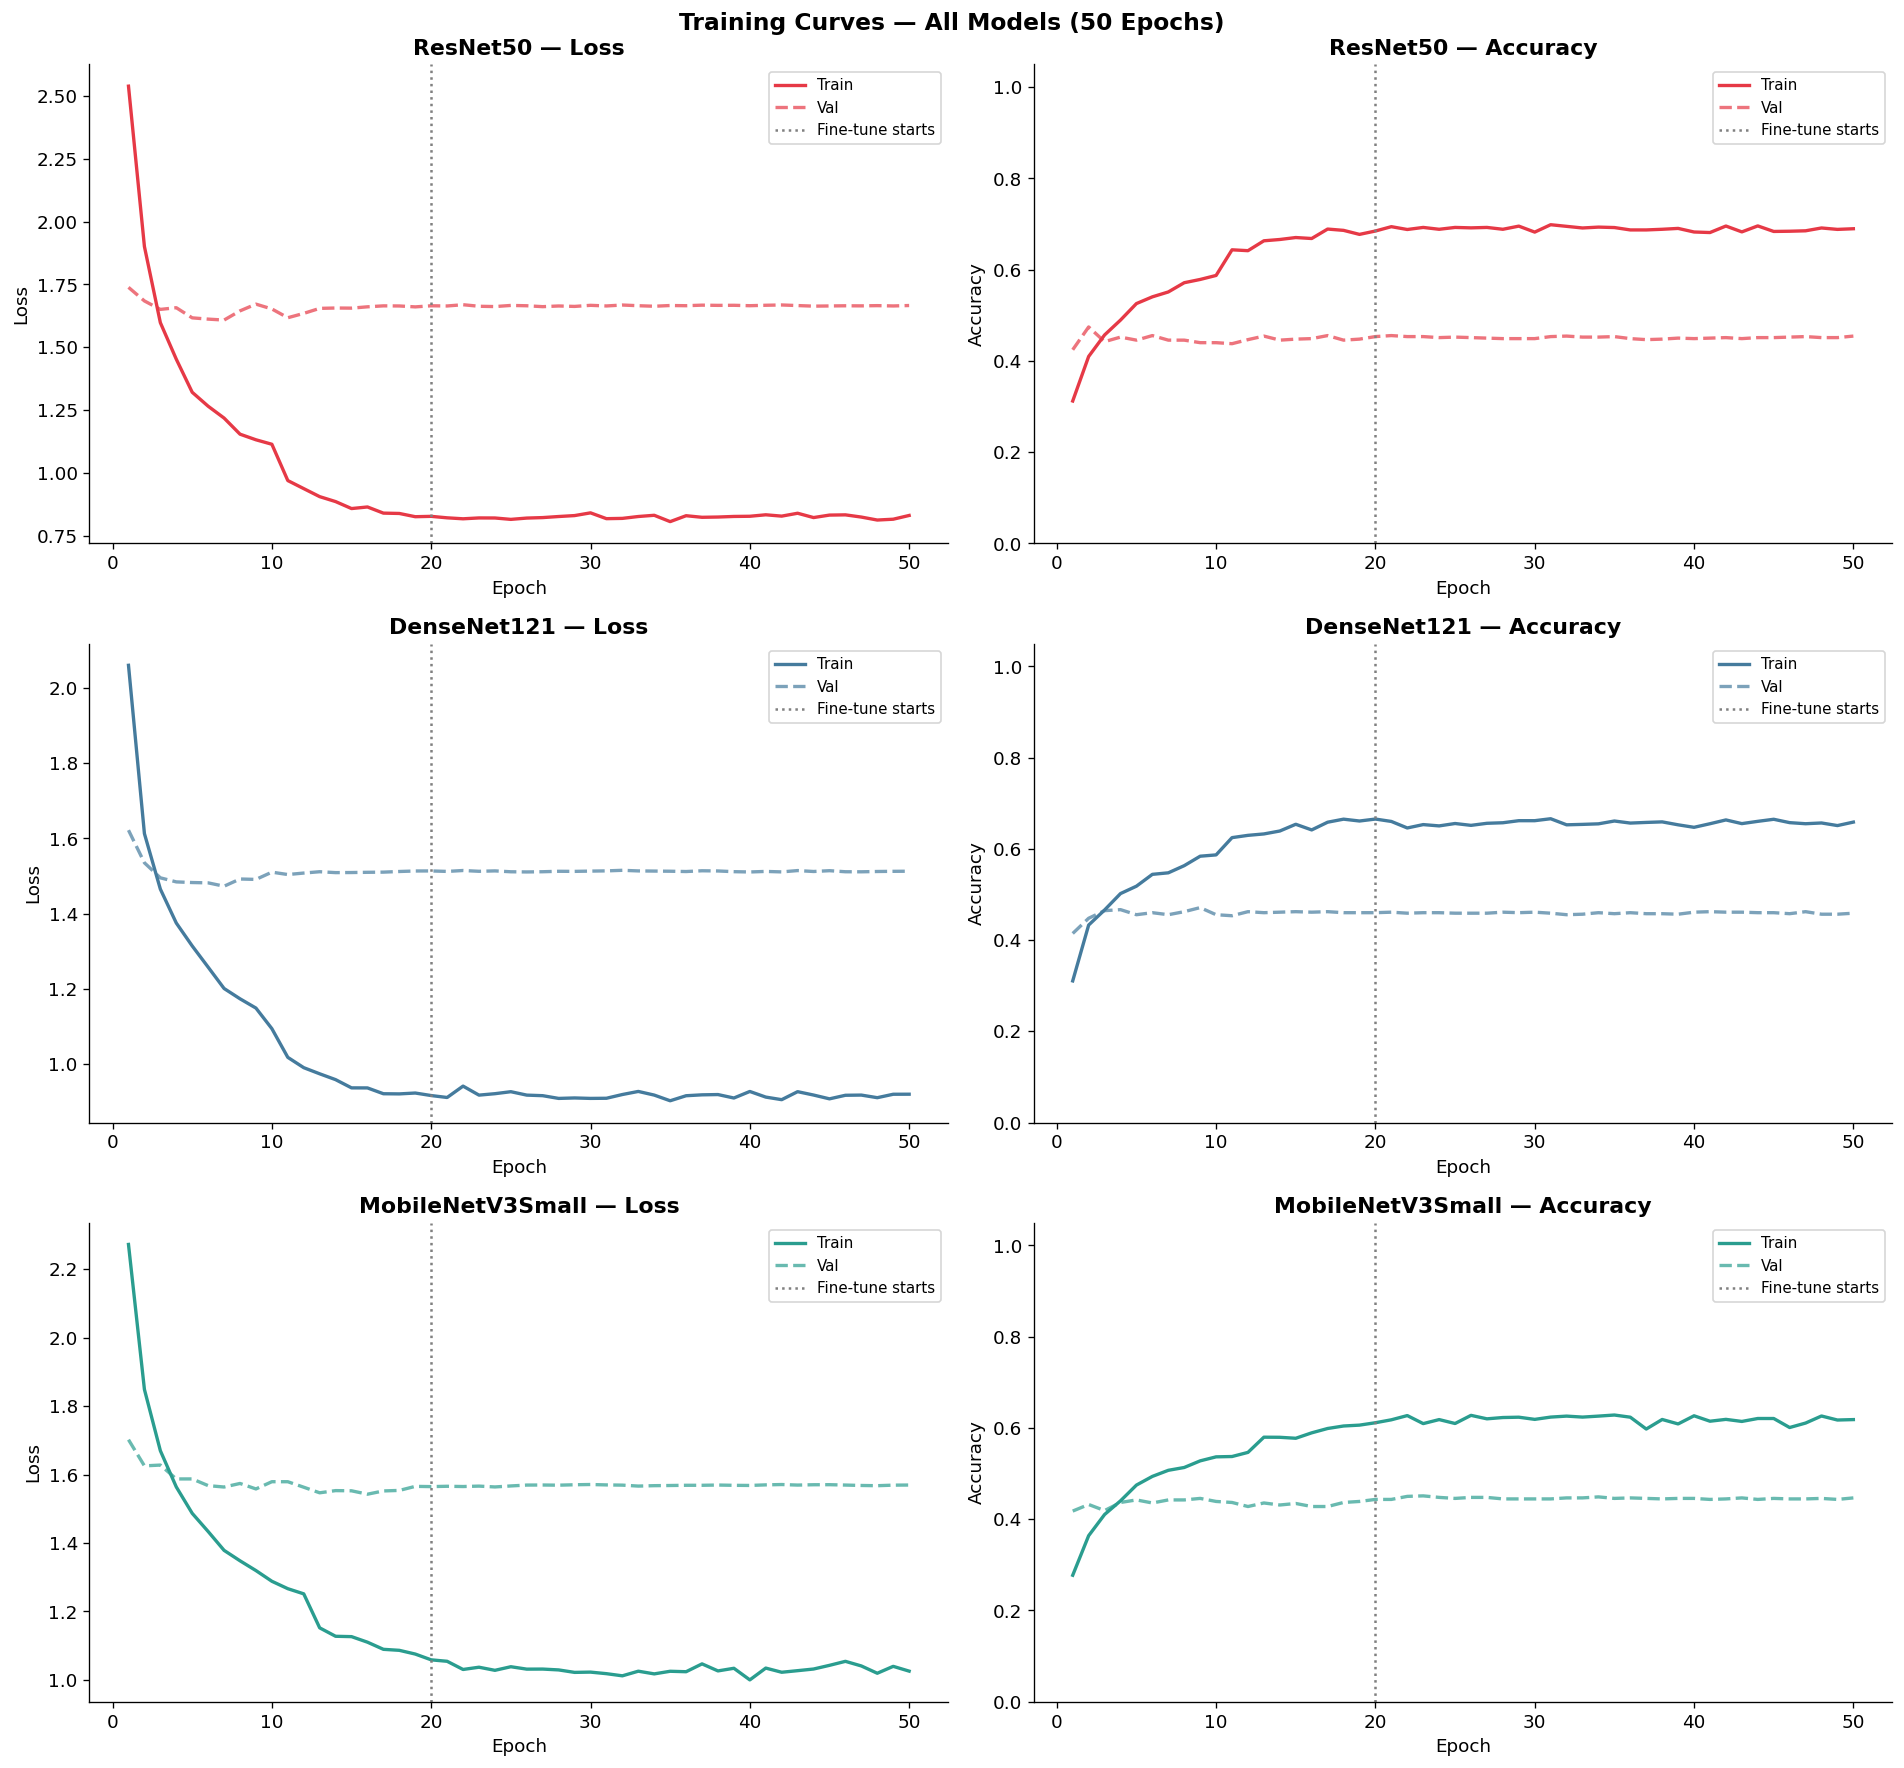

Saved viz_02_training_curves.png


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for row, (name, color) in enumerate(COLORS.items()):
    if name not in results: continue
    hist = results[name]['history']
    ep   = range(1, len(hist['accuracy']) + 1)

    axes[row,0].plot(ep, hist['loss'],     color=color, lw=2, label='Train')
    axes[row,0].plot(ep, hist['val_loss'], color=color, lw=2, ls='--', alpha=0.7, label='Val')
    axes[row,0].axvline(20, color='grey', ls=':', lw=1.5, label='Fine-tune starts')
    axes[row,0].set_title(f'{name} — Loss', fontweight='bold')
    axes[row,0].set_xlabel('Epoch')
    axes[row,0].set_ylabel('Loss')
    axes[row,0].legend(fontsize=9)

    axes[row,1].plot(ep, hist['accuracy'],     color=color, lw=2, label='Train')
    axes[row,1].plot(ep, hist['val_accuracy'], color=color, lw=2, ls='--', alpha=0.7, label='Val')
    axes[row,1].axvline(20, color='grey', ls=':', lw=1.5, label='Fine-tune starts')
    axes[row,1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[row,1].set_xlabel('Epoch')
    axes[row,1].set_ylabel('Accuracy')
    axes[row,1].set_ylim(0, 1.05)
    axes[row,1].legend(fontsize=9)

plt.suptitle('Training Curves — All Models (50 Epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_02_training_curves.png', bbox_inches='tight')
plt.show()
print('Saved viz_02_training_curves.png')

---
# 3. Confusion Matrices

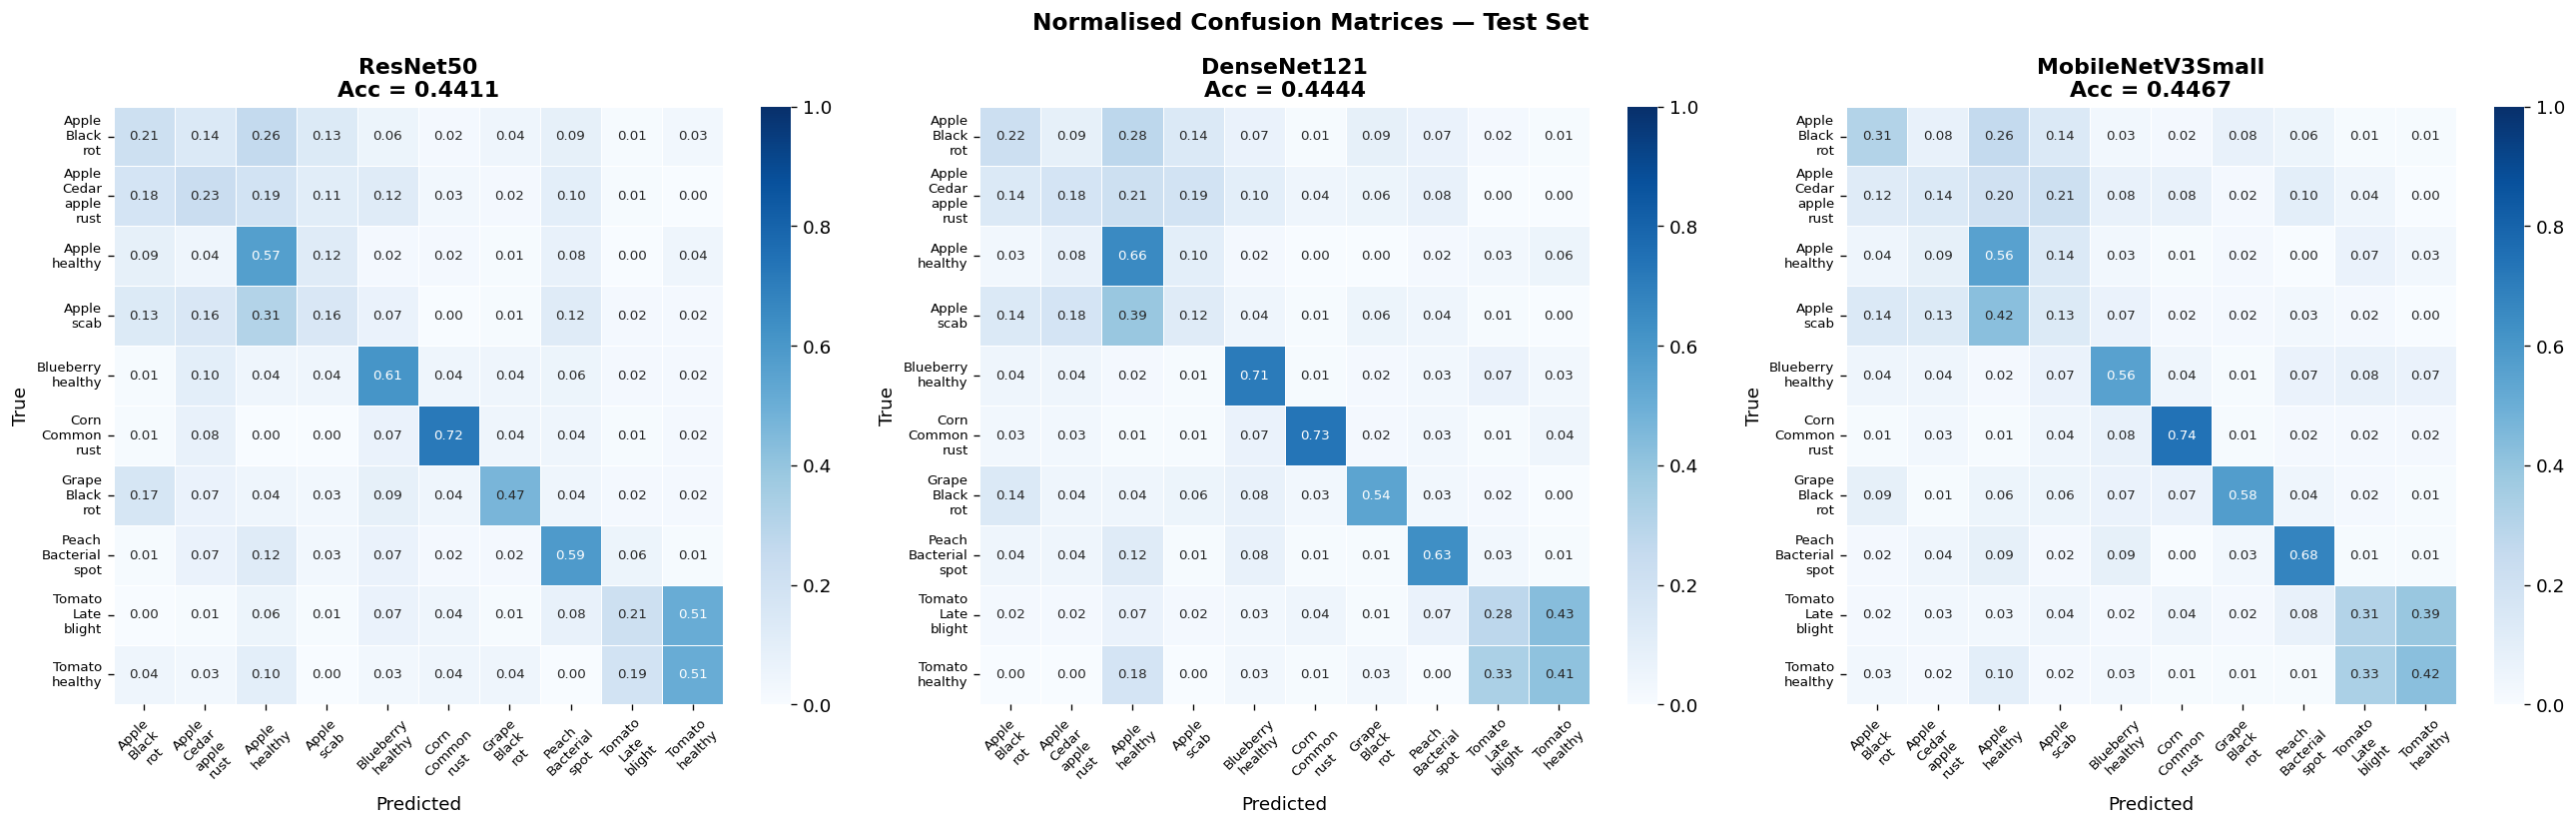

Saved viz_03_confusion_matrices.png


In [13]:
short = [c.replace('_','\n') for c in CLASS_NAMES]
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, color) in zip(axes, COLORS.items()):
    if name not in y_preds:
        ax.set_visible(False); continue
    cm      = confusion_matrix(y_true, y_preds[name])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short, yticklabels=short,
                ax=ax, linewidths=0.5, vmin=0, vmax=1,
                annot_kws={'size': 8})
    ax.set_title(
        f'{name}\nAcc = {results[name]["test_acc"]:.4f}',
        fontweight='bold'
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Normalised Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_03_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved viz_03_confusion_matrices.png')

---
# 4. Per-Class Average Precision

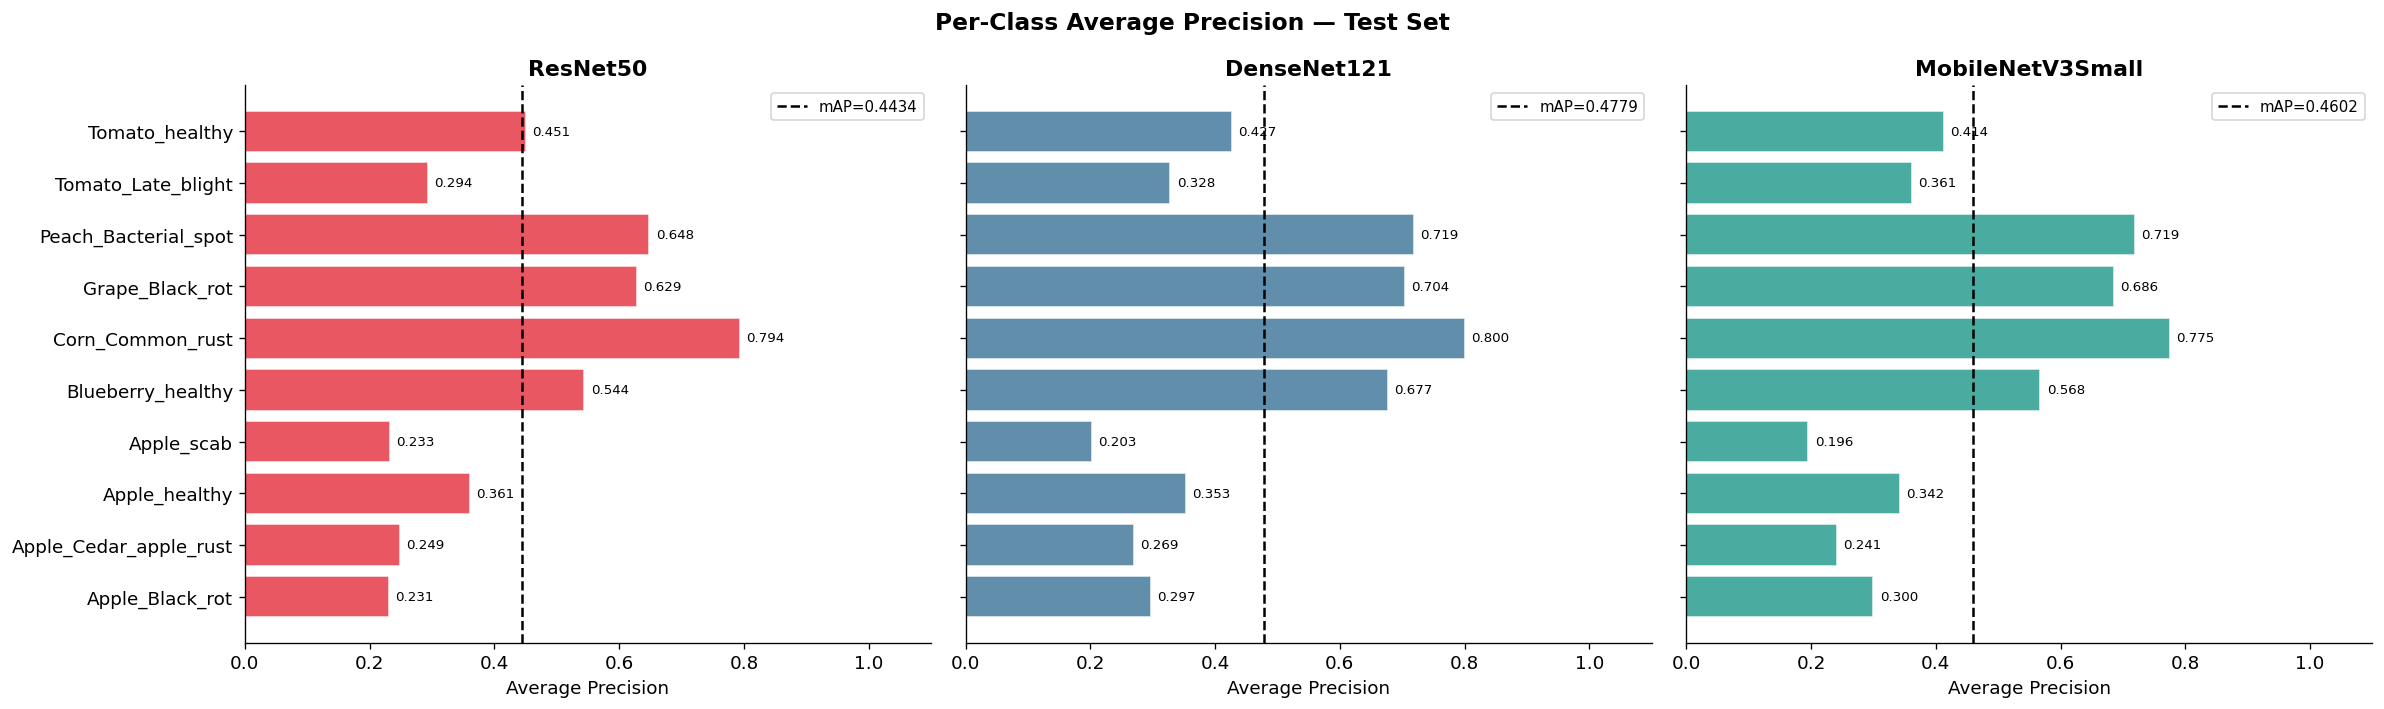

Saved viz_04_per_class_AP.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (name, color) in zip(axes, COLORS.items()):
    if name not in results: continue
    aps     = results[name]['per_class_AP']
    mean_ap = results[name]['mAP']
    bars = ax.barh(CLASS_NAMES, aps, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(mean_ap, color='black', ls='--', lw=1.5, label=f'mAP={mean_ap:.4f}')
    ax.set_xlim(0, 1.1)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Average Precision')
    ax.legend(fontsize=9)
    for bar, ap in zip(bars, aps):
        ax.text(bar.get_width()+0.01,
                bar.get_y()+bar.get_height()/2,
                f'{ap:.3f}', va='center', fontsize=8)

plt.suptitle('Per-Class Average Precision — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_per_class_AP.png', bbox_inches='tight')
plt.show()
print('Saved viz_04_per_class_AP.png')

---
# 5. Model Comparison

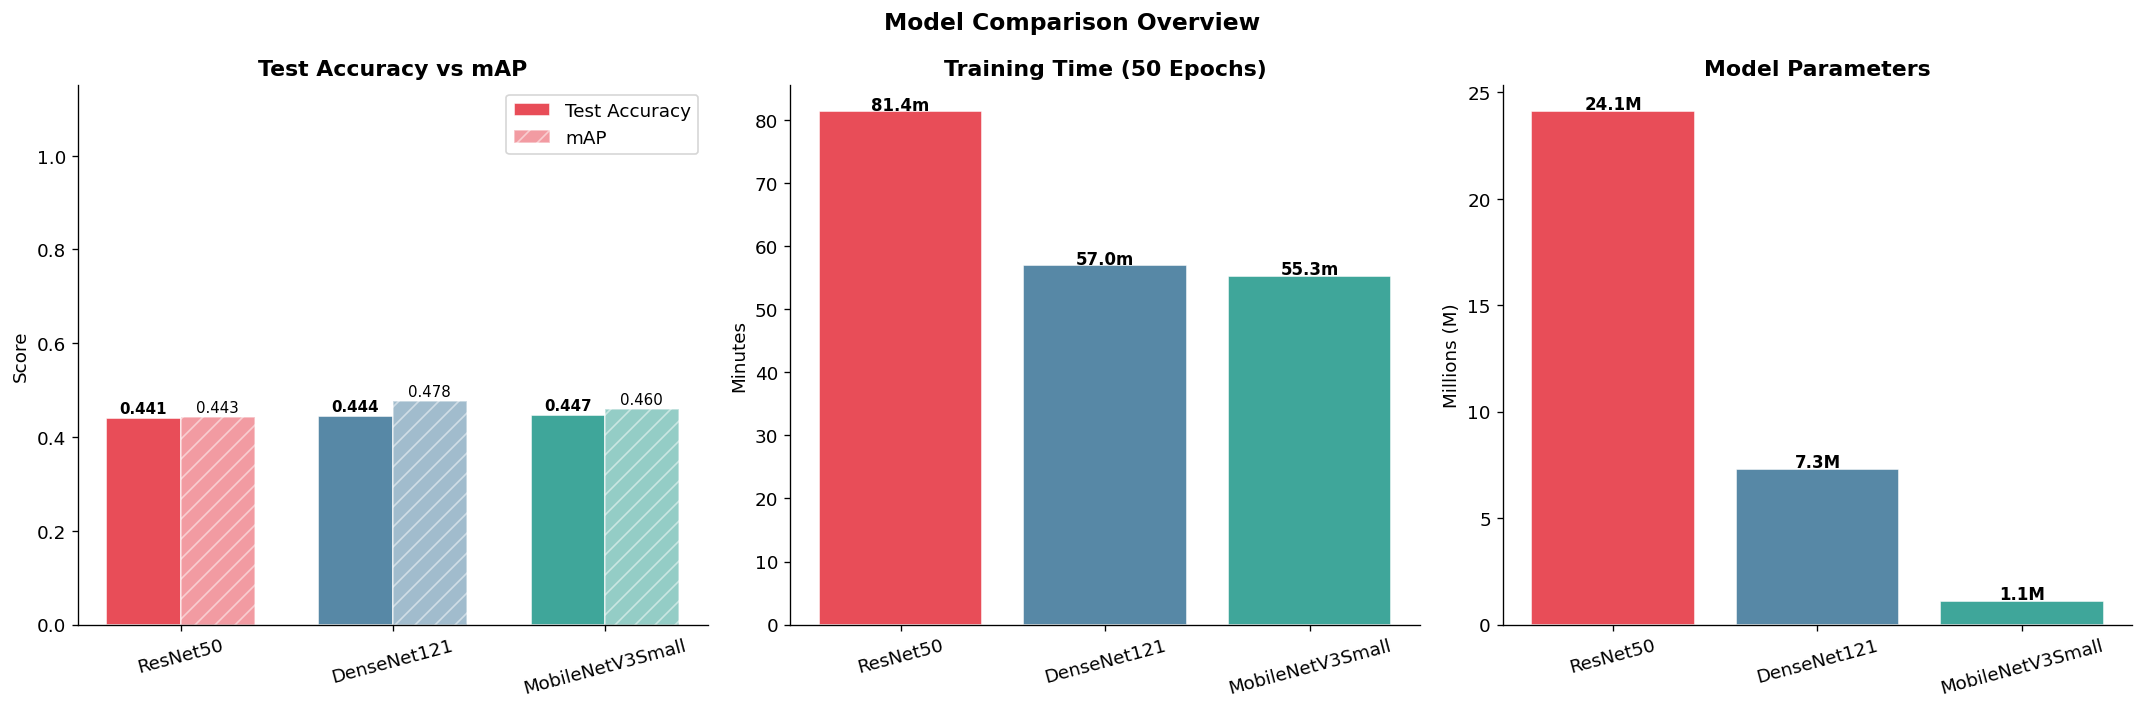

Saved viz_05_model_comparison.png


In [15]:
names  = list(results.keys())
accs   = [results[m]['test_acc']       for m in names]
maps   = [results[m]['mAP']            for m in names]
times  = [results[m]['train_time_min'] for m in names]
params = [results[m]['params']/1e6     for m in names]
colors = [COLORS[m]                    for m in names]
x, w   = np.arange(len(names)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy vs mAP
axes[0].bar(x-w/2, accs, w, label='Test Accuracy',
            color=colors, alpha=0.9, edgecolor='white')
axes[0].bar(x+w/2, maps, w, label='mAP',
            color=colors, alpha=0.5, edgecolor='white', hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('Test Accuracy vs mAP', fontweight='bold')
axes[0].legend()
for i,(a,m) in enumerate(zip(accs,maps)):
    axes[0].text(i-w/2, a+0.01, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i+w/2, m+0.01, f'{m:.3f}', ha='center', fontsize=9)

# Training time
bars = axes[1].bar(names, times, color=colors, alpha=0.9, edgecolor='white')
axes[1].set_ylabel('Minutes')
axes[1].set_title('Training Time (50 Epochs)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
for bar, t in zip(bars, times):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.2,
                 f'{t:.1f}m', ha='center', fontsize=10, fontweight='bold')

# Parameters
bars = axes[2].bar(names, params, color=colors, alpha=0.9, edgecolor='white')
axes[2].set_ylabel('Millions (M)')
axes[2].set_title('Model Parameters', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
for bar, p in zip(bars, params):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.1,
                 f'{p:.1f}M', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_05_model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved viz_05_model_comparison.png')

---
# 6. Validation Curves Overlay

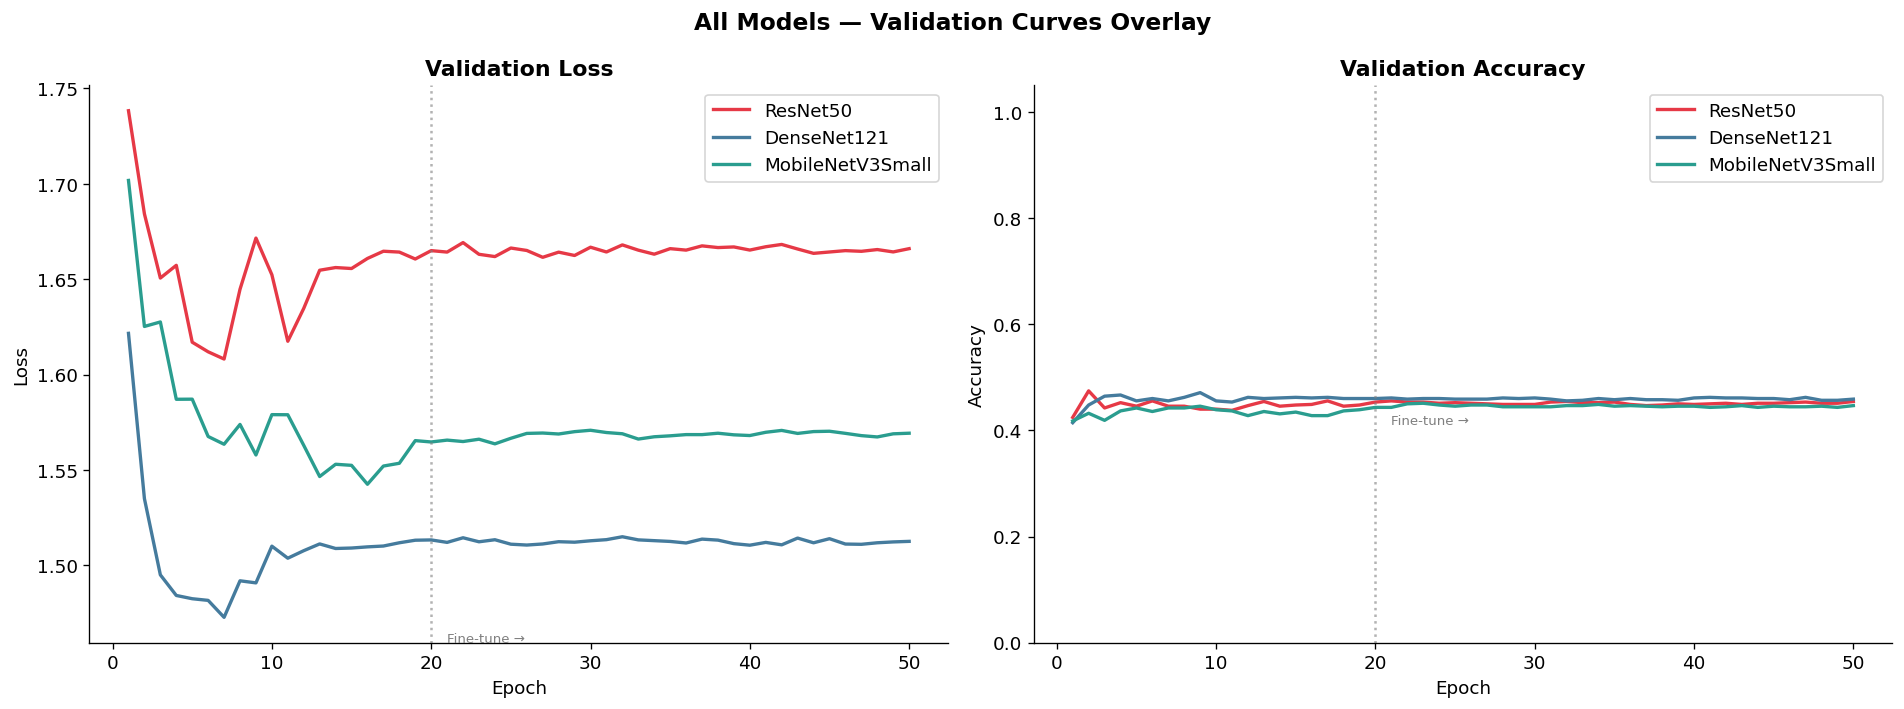

Saved viz_06_val_overlay.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, color in COLORS.items():
    if name not in results: continue
    hist = results[name]['history']
    ep   = range(1, len(hist['val_accuracy']) + 1)
    axes[0].plot(ep, hist['val_loss'],     color=color, lw=2, label=name)
    axes[1].plot(ep, hist['val_accuracy'], color=color, lw=2, label=name)

for ax, title, ylabel in zip(
    axes,
    ['Validation Loss', 'Validation Accuracy'],
    ['Loss', 'Accuracy']
):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.axvline(20, color='grey', ls=':', lw=1.5, alpha=0.6)
    ax.text(21, ax.get_ylim()[0], 'Fine-tune →', fontsize=8, color='grey')

axes[1].set_ylim(0, 1.05)
plt.suptitle('All Models — Validation Curves Overlay', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_06_val_overlay.png', bbox_inches='tight')
plt.show()
print('Saved viz_06_val_overlay.png')

---
# 7. Radar Chart

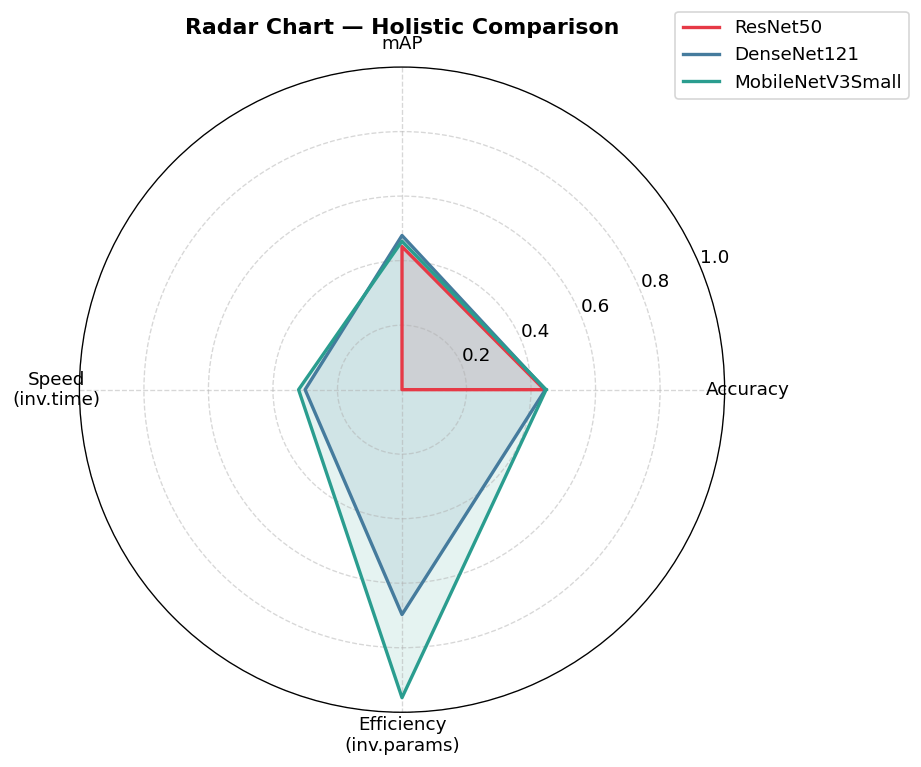

Saved viz_07_radar_chart.png


In [17]:
metrics = ['Accuracy', 'mAP', 'Speed\n(inv.time)', 'Efficiency\n(inv.params)']
N       = len(metrics)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

max_time   = max(results[m]['train_time_min'] for m in results)
max_params = max(results[m]['params']         for m in results)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, color in COLORS.items():
    if name not in results: continue
    r = results[name]
    vals = [
        r['test_acc'],
        r['mAP'],
        1 - r['train_time_min'] / max_time,
        1 - r['params'] / max_params
    ]
    vals += vals[:1]
    ax.plot(angles, vals, color=color, lw=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.12)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Holistic Comparison', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('viz_07_radar_chart.png', bbox_inches='tight')
plt.show()
print('Saved viz_07_radar_chart.png')

---
# Classification Report

In [18]:
for name in COLORS:
    if name not in y_preds: continue
    print(f'\n{"="*60}\n  {name}\n{"="*60}')
    print(classification_report(y_true, y_preds[name], target_names=CLASS_NAMES))


  ResNet50
                        precision    recall  f1-score   support

       Apple_Black_rot       0.25      0.21      0.23        90
Apple_Cedar_apple_rust       0.25      0.23      0.24        90
         Apple_healthy       0.34      0.57      0.42        90
            Apple_scab       0.24      0.16      0.19        90
     Blueberry_healthy       0.51      0.61      0.56        90
      Corn_Common_rust       0.72      0.72      0.72        90
       Grape_Black_rot       0.65      0.47      0.54        90
  Peach_Bacterial_spot       0.49      0.59      0.54        90
    Tomato_Late_blight       0.38      0.21      0.27        90
        Tomato_healthy       0.43      0.51      0.46        90

              accuracy                           0.43       900
             macro avg       0.42      0.43      0.42       900
          weighted avg       0.42      0.43      0.42       900


  DenseNet121
                        precision    recall  f1-score   support

       Ap

---
# Final Conclusion

In [19]:
best_acc = max(results, key=lambda m: results[m]['test_acc'])
best_map = max(results, key=lambda m: results[m]['mAP'])
fastest  = min(results, key=lambda m: results[m]['train_time_min'])
smallest = min(results, key=lambda m: results[m]['params'])

max_t = max(results[m]['train_time_min'] for m in results)
max_p = max(results[m]['params']         for m in results)

composite = {
    m: (0.40 * results[m]['test_acc']
      + 0.40 * results[m]['mAP']
      + 0.10 * (1 - results[m]['train_time_min'] / max_t)
      + 0.10 * (1 - results[m]['params'] / max_p))
    for m in results
}
best = max(composite, key=composite.get)

print('=' * 65)
print('  FINAL CONCLUSION')
print('=' * 65)
print(f'\n{"Model":<22} {"Acc":>7} {"mAP":>7} {"Time(m)":>9} {"Params":>10} {"Score":>7}')
print('-' * 65)
for m in results:
    marker = '  ◀ BEST' if m == best else ''
    print(f'{m:<22} {results[m]["test_acc"]:>7.4f} {results[m]["mAP"]:>7.4f}'
          f' {results[m]["train_time_min"]:>9.1f} {results[m]["params"]/1e6:>9.1f}M'
          f' {composite[m]:>7.4f}{marker}')

print(f'''
{'='*65}
  Best Accuracy  → {best_acc}
  Best mAP       → {best_map}
  Fastest        → {fastest}
  Lightest       → {smallest}
  OVERALL BEST   → {best}  (composite score)
{'='*65}

ANALYSIS
--------
ResNet50 (~25M params)
  Uses residual/skip connections to preserve gradient flow across
  50 layers. Strong feature extractor but the heaviest and slowest
  model of the three.

DenseNet121 (~8M params)
  Each layer receives feature maps from all previous layers,
  enabling maximum feature reuse with fewer parameters than ResNet50.
  Consistently competitive on plant and medical imaging tasks.

MobileNetV3Small (~2.5M params)
  Depthwise separable convolutions reduce computation drastically.
  Fastest training and smallest memory footprint — ideal for edge
  or mobile deployment despite slightly lower absolute accuracy.

RECOMMENDATION
--------------
For server-side deployment (no memory constraint):
  → {best_acc}  (highest accuracy)
For mobile / embedded / real-time deployment:
  → MobileNetV3Small  (fastest, lightest)
Balanced choice (accuracy + mAP + speed + efficiency):
  → {best}  (best composite score)
''')

  FINAL CONCLUSION

Model                      Acc     mAP   Time(m)     Params   Score
-----------------------------------------------------------------
ResNet50                0.4411  0.4434      81.4      24.1M  0.3538
DenseNet121             0.4444  0.4779      57.0       7.3M  0.4687
MobileNetV3Small        0.4467  0.4602      55.3       1.1M  0.4903  ◀ BEST

  Best Accuracy  → MobileNetV3Small
  Best mAP       → DenseNet121
  Fastest        → MobileNetV3Small
  Lightest       → MobileNetV3Small
  OVERALL BEST   → MobileNetV3Small  (composite score)

ANALYSIS
--------
ResNet50 (~25M params)
  Uses residual/skip connections to preserve gradient flow across
  50 layers. Strong feature extractor but the heaviest and slowest
  model of the three.

DenseNet121 (~8M params)
  Each layer receives feature maps from all previous layers,
  enabling maximum feature reuse with fewer parameters than ResNet50.
  Consistently competitive on plant and medical imaging tasks.

MobileNetV3Small (~2.